In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from keras.layers import Activation, BatchNormalization, Conv2D, Conv1D
from keras import initializers

from scipy.interpolate import interp1d

import lasio

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

2024-06-07 12:28:00.948071: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-07 12:28:00.948158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-07 12:28:00.951645: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-06-07 12:28:00.970194: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-07 12:28:01.942080: W tensorflow/compiler/tf2

In [2]:
seis_exploration = np.load('../data_decatur/processed/exploration_block.npy')
phi_exploration = np.load('../data_decatur/processed/exploration_block_porosity.npy')

ccs1 = lasio.read('../data_decatur/wells/ccs1_phie_smoothed.las')
vw1 = lasio.read('../data_decatur/wells/vw1_phie_smoothed.las')

In [3]:
given_seed=2

def naive_model():
    """El input shape de tal forma sería entonces (1, 246) ya que son trazas sismicas, 2000 de ellas"""

    model = tf.keras.models.Sequential()
        #probar a poner capa densa al comienzo y luego pasar por la convolución
    input_final = tf.keras.Input(shape=(1, 124))
    model.add(input_final)
    #model.add(tf.keras.layers.Reshape((-1,1)))
    
    model.add(Conv1D(filters=128, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=256, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=512, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    
    model.add(Conv1D(filters=1024, kernel_size=3, strides=1, padding='same',kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')) 
    model.add(Activation('tanh'))
    model.add(tf.keras.layers.Dropout(rate=0.3))
    

    model.add(tf.keras.layers.Flatten())
 
    
    model.add(tf.keras.layers.Dense(units=124,kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros'))
    model.add(Activation('tanh'))

    return model
    

model_phi = naive_model()
model_phi.build((None,124,1))
model_phi.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1, 128)            47744     
                                                                 
 activation (Activation)     (None, 1, 128)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 1, 256)            98560     
                                                                 
 activation_1 (Activation)   (None, 1, 256)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 1, 512)            393728    


2024-06-07 12:28:03.321883: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-07 12:28:03.378339: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-07 12:28:03.378447: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-07 12:28:03.382674: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-07 12:28:03.382773: I external/local_xla/xla/stream_executor

                                                                 
 activation_2 (Activation)   (None, 1, 512)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 1, 1024)           1573888   
                                                                 
 activation_3 (Activation)   (None, 1, 1024)           0         
                                                                 
 dropout (Dropout)           (None, 1, 1024)           0         
                                                                 
 flatten (Flatten)           (None, 1024)              0         
                                                                 
 dense (Dense)               (None, 124)               127100    
                                                                 
 activation_4 (Activation)   (None, 124)               0         
                                                                 
Total para

In [4]:
model_phi.load_weights('model_naive.h5')

In [5]:
def min_max_scale(x, min, max):

  x_std = (x - min) / (max - min)
  x_scaled = x_std * 2 - 1
  return x_scaled

def inverse_min_max_scale(x, min, max):

  x_normalized = (x + 1) / 2
  x_unscaled = x_normalized * (max - min) + min
  return x_unscaled

In [6]:
phi_max=np.max(phi_exploration) #can also take 1 or critical porosity (0.4)
phi_min=np.min(phi_exploration) #can also take 0

In [7]:
seis_normalized = (seis_exploration - np.min(seis_exploration))/(np.max(seis_exploration)-np.min(seis_exploration))
X_exploracion = seis_normalized.reshape(-1, 124)

X_exploracion = np.expand_dims(X_exploracion, axis=1)
phi_pred_exploracion = model_phi.predict(X_exploracion)
phi_pred_exploracion = inverse_min_max_scale(phi_pred_exploracion, phi_min, phi_max)

2024-06-07 12:28:04.509297: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-06-07 12:28:04.785597: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


2116/2116 [==============================] - 6s 3ms/step


In [8]:
seis_exploration.shape

(183, 370, 124)

In [9]:
phi_pred_exploracion = phi_pred_exploracion.reshape(183, 370, 124)

Necesito extraer la sección exacta por donde pasa el pozo, para eso necesito conocer el rango e IL y XL, eso está en el archivo data prep de la sismica y tambien necesito conocer en que inline y xline estan los pozos para visualizarlos

Amplitude Inline range: 13 - 195

Amplitude Crossline range: 930 - 2140

In [10]:
df_ccs1 = ccs1.df()
df_vw1 = vw1.df()

In [11]:
df_ccs1

,SMOOTHED_PIGN
DEPT,
5039.0,NaN
5039.5,NaN
5040.0,NaN
5040.5,NaN
5041.0,NaN
...,...
7234.0,NaN
7234.5,NaN
7235.0,NaN


In [12]:
new_data_depth_start = 5039
new_data_depth_end = 7236
new_data_depth_step = 0.5
new_data_depth_values = np.arange(new_data_depth_start, new_data_depth_end + new_data_depth_step, new_data_depth_step)

# Determine the overlapping depth range
min_depth = max(4530, new_data_depth_start)
max_depth = min(7010, new_data_depth_end)
overlap_depth_values = np.arange(min_depth, max_depth + 20, 20)

# Resample the new data to match the depth values of the image
f = interp1d(new_data_depth_values, df_ccs1.values.ravel())
resampled_new_data = f(overlap_depth_values)

In [13]:
depth_start = 4530
depth_end = 7010
depth_step = 20
depth_values = np.arange(depth_start, depth_end , depth_step)
num_ticks = 6  # Adjust the number of ticks as needed
depth_indices = np.linspace(0, len(depth_values) - 1, num_ticks, dtype=int)

In [14]:
depth_diff = int((5039-4530)/20)

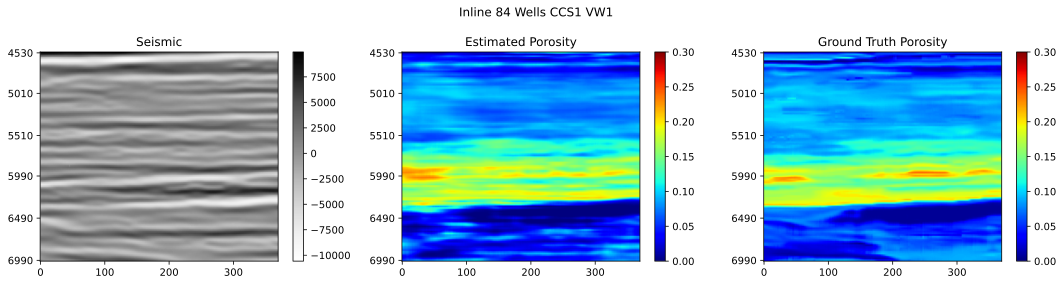

In [15]:
fig, ax = plt.subplots(1,3, figsize = (15, 4))
line_location=150
fig.suptitle('Inline 84 Wells CCS1 VW1')

im1 = ax[0].imshow(seis_exploration[84-13,:,:].T, cmap='Greys')
ax[0].set_title('Seismic')
ax[0].set_aspect('auto')
ax[0].set_yticks(depth_indices)
ax[0].set_yticklabels(depth_values[depth_indices])
fig.colorbar(im1, ax=ax[0], shrink=1)

im2 = ax[1].imshow(phi_pred_exploracion[84-13,:,:].T, vmin=0, vmax=0.3, cmap='jet')
ax[1].set_title('Estimated Porosity')
ax[1].set_aspect('auto')
ax[1].set_yticks(depth_indices)
ax[1].set_yticklabels(depth_values[depth_indices])
plot_depth_values = np.arange(len(overlap_depth_values)) + depth_diff
#ax[1].plot(resampled_new_data + line_location, plot_depth_values, color='red')

fig.colorbar(im2, ax=ax[1], shrink=1)

im3 = ax[2].imshow(phi_exploration[84-13,:,:].T, vmin=0, vmax=0.3, cmap='jet')
ax[2].set_title('Ground Truth Porosity')
ax[2].set_aspect('auto')
ax[2].set_yticks(depth_indices)
ax[2].set_yticklabels(depth_values[depth_indices])
fig.colorbar(im3, ax=ax[2], shrink=1)
fig.tight_layout()
        
fig.savefig("./plots/section_predicted_inline.png")
fig.savefig("./plots/section_predicted_inline.pdf", format="pdf", bbox_inches="tight")
plt.show()
